/tmp/ipykernel_6830/2170515312.py:90: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6830/2170515312.py:91: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  plt.savefig("day10_popculture.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127916 (\N{CLAPPER BOARD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


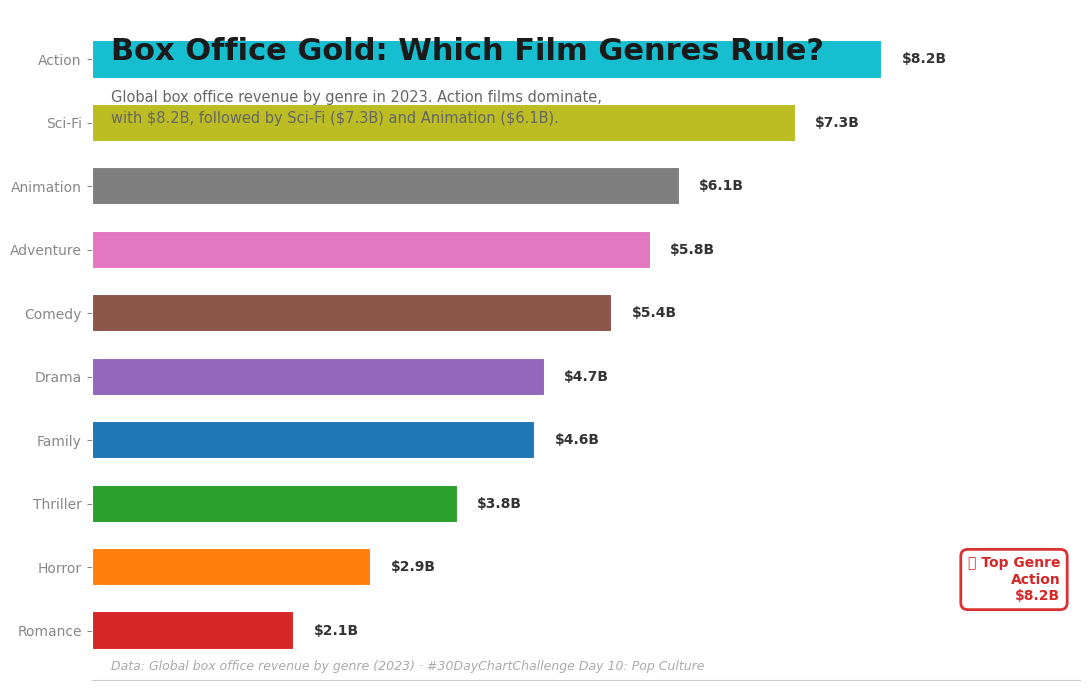

In [1]:
"""
#30DayChartChallenge — Day 10: Pop Culture
"Movie Box Office by Genre" — distribution of global film revenue
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Global box office revenue by film genre (2023)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Global box office revenue by genre (Billions USD)
# ---------------------------------------------------------------------------
data = {
    "Genre": [
        "Action",
        "Comedy",
        "Drama",
        "Animation",
        "Thriller",
        "Horror",
        "Romance",
        "Adventure",
        "Sci-Fi",
        "Family"
    ],
    "Box_Office": [8.2, 5.4, 4.7, 6.1, 3.8, 2.9, 2.1, 5.8, 7.3, 4.6]
}

df = pd.DataFrame(data)
df = df.sort_values("Box_Office", ascending=True)

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 7), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Color palette: vibrant colors for each genre
palette = [
    "#d62728", "#ff7f0e", "#2ca02c", "#1f77b4", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"
]

# Horizontal bar chart
bars = ax.barh(range(len(df)), df["Box_Office"], height=0.6, 
               color=palette, edgecolor="white", linewidth=1.5, zorder=3)

# Add value labels on the bars
for i, (idx, row) in enumerate(df.iterrows()):
    ax.text(row["Box_Office"] + 0.2, i, f"${row['Box_Office']:.1f}B",
            fontsize=10, fontweight="600", color="#333333", va="center")

# Y-axis labels
ax.set_yticks(range(len(df)))
ax.set_yticklabels(df["Genre"], fontsize=11, fontweight="500", color="#333333")

# Minimal styling
ax.set_xlim(0, df["Box_Office"].max() * 1.25)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.xaxis.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, zorder=0)
ax.set_axisbelow(True)
ax.set_xticks([])
ax.tick_params(colors="#888888", labelsize=10)

# Title & subtitle
ax.text(0.02, 0.96, "Box Office Gold: Which Film Genres Rule?",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.88,
        "Global box office revenue by genre in 2023. Action films dominate,\n"
        "with $8.2B, followed by Sci-Fi ($7.3B) and Animation ($6.1B).",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Highlight top genre
top_genre = df.iloc[-1]
ax.text(0.98, 0.15, f"🎬 Top Genre\n{top_genre['Genre']}\n${top_genre['Box_Office']:.1f}B",
        fontsize=10, fontweight="bold", color="#d62728", transform=ax.transAxes, 
        ha="right", va="center", bbox=dict(boxstyle="round,pad=0.5",
        facecolor="#fff", edgecolor="#d62728", linewidth=2, alpha=0.95))

# Source
ax.text(0.02, 0.01,
        "Data: Global box office revenue by genre (2023) · #30DayChartChallenge Day 10: Pop Culture",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day10_popculture.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()